# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

 # **1. Sumber Dataset**

Dataset yang digunakan dalam eksperimen ini adalah **Credit Risk Dataset** yang diperoleh dari Kaggle.
https://www.kaggle.com/datasets/laotse/credit-risk-dataset

**Informasi Dataset:**
- **Sumber**: Kaggle (Credit Risk Dataset oleh Lao Tse)
- **Jumlah Data**: 32.581 baris
- **Jumlah Fitur**: 12 kolom
- **Tipe Masalah**: Klasifikasi Biner (Prediksi risiko kredit)
- **Target**: `loan_status` (0 = Tidak Default, 1 = Default)

**Deskripsi Fitur:**
| Fitur | Deskripsi |
|---|---|
| person_age | Usia peminjam |
| person_income | Pendapatan tahunan peminjam |
| person_home_ownership | Status kepemilikan rumah (RENT, OWN, MORTGAGE, OTHER) |
| person_emp_length | Lama bekerja (tahun) |
| loan_intent | Tujuan pinjaman |
| loan_grade | Grade pinjaman (A-G) |
| loan_amnt | Jumlah pinjaman |
| loan_int_rate | Suku bunga pinjaman |
| loan_status | Status pinjaman (0=Tidak Default, 1=Default) |
| loan_percent_income | Rasio pinjaman terhadap pendapatan |
| cb_person_default_on_file | Riwayat default sebelumnya (Y/N) |
| cb_person_cred_hist_length | Panjang riwayat kredit (tahun) |


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [14]:
# Ubah '../credit_risk_dataset.csv' menjadi 'credit_risk_dataset.csv'
df = pd.read_csv('credit_risk_dataset.csv')
print(f'Dataset berhasil dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.')
df.head(10)


Dataset berhasil dimuat dengan 32581 baris dan 12 kolom.


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [15]:
# Melihat 5 baris pertama dataset
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [16]:
# Melihat info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [17]:
# Statistik deskriptif
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [21]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [22]:
df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [23]:
print('Jumlah Missing Values per Kolom:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(f'\nPersentase Missing Values:')
print((df.isnull().sum() / len(df) * 100).round(2))

Jumlah Missing Values per Kolom:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Total missing values: 4011

Persentase Missing Values:
person_age                    0.00
person_income                 0.00
person_home_ownership         0.00
person_emp_length             2.75
loan_intent                   0.00
loan_grade                    0.00
loan_amnt                     0.00
loan_int_rate                 9.56
loan_status                   0.00
loan_percent_income           0.00
cb_person_default_on_file     0.00
cb_person_cred_hist_length    0.00
dtype: float64


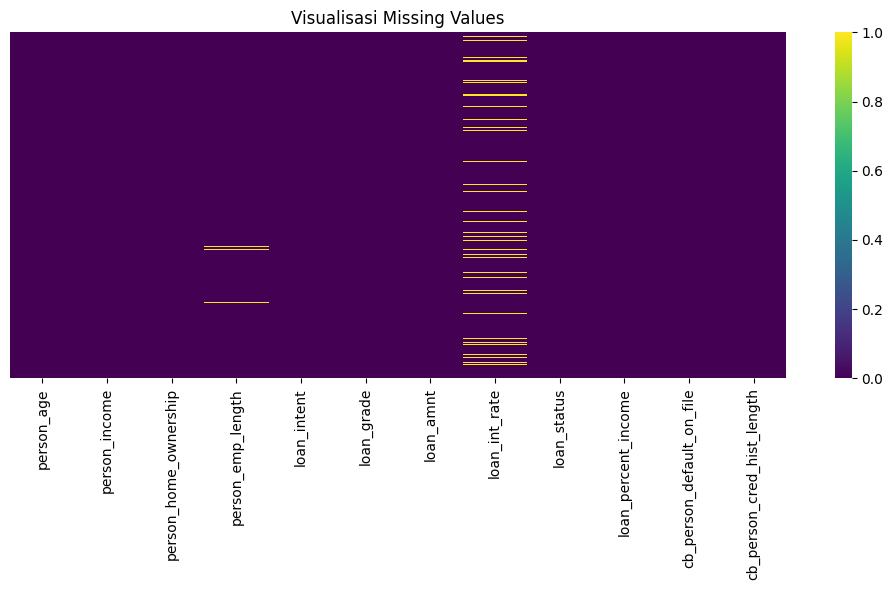

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Visualisasi Missing Values')
plt.tight_layout()
plt.show()

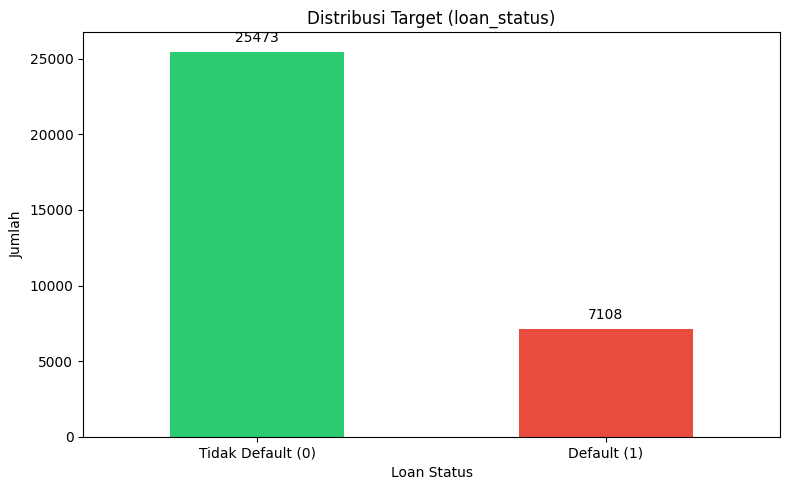


Proporsi Target:
loan_status
0    0.7818
1    0.2182
Name: proportion, dtype: float64


In [25]:
plt.figure(figsize=(8, 5))
ax = df['loan_status'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Target (loan_status)')
plt.xlabel('Loan Status')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Tidak Default (0)', 'Default (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

print(f'\nProporsi Target:')
print(df['loan_status'].value_counts(normalize=True).round(4))

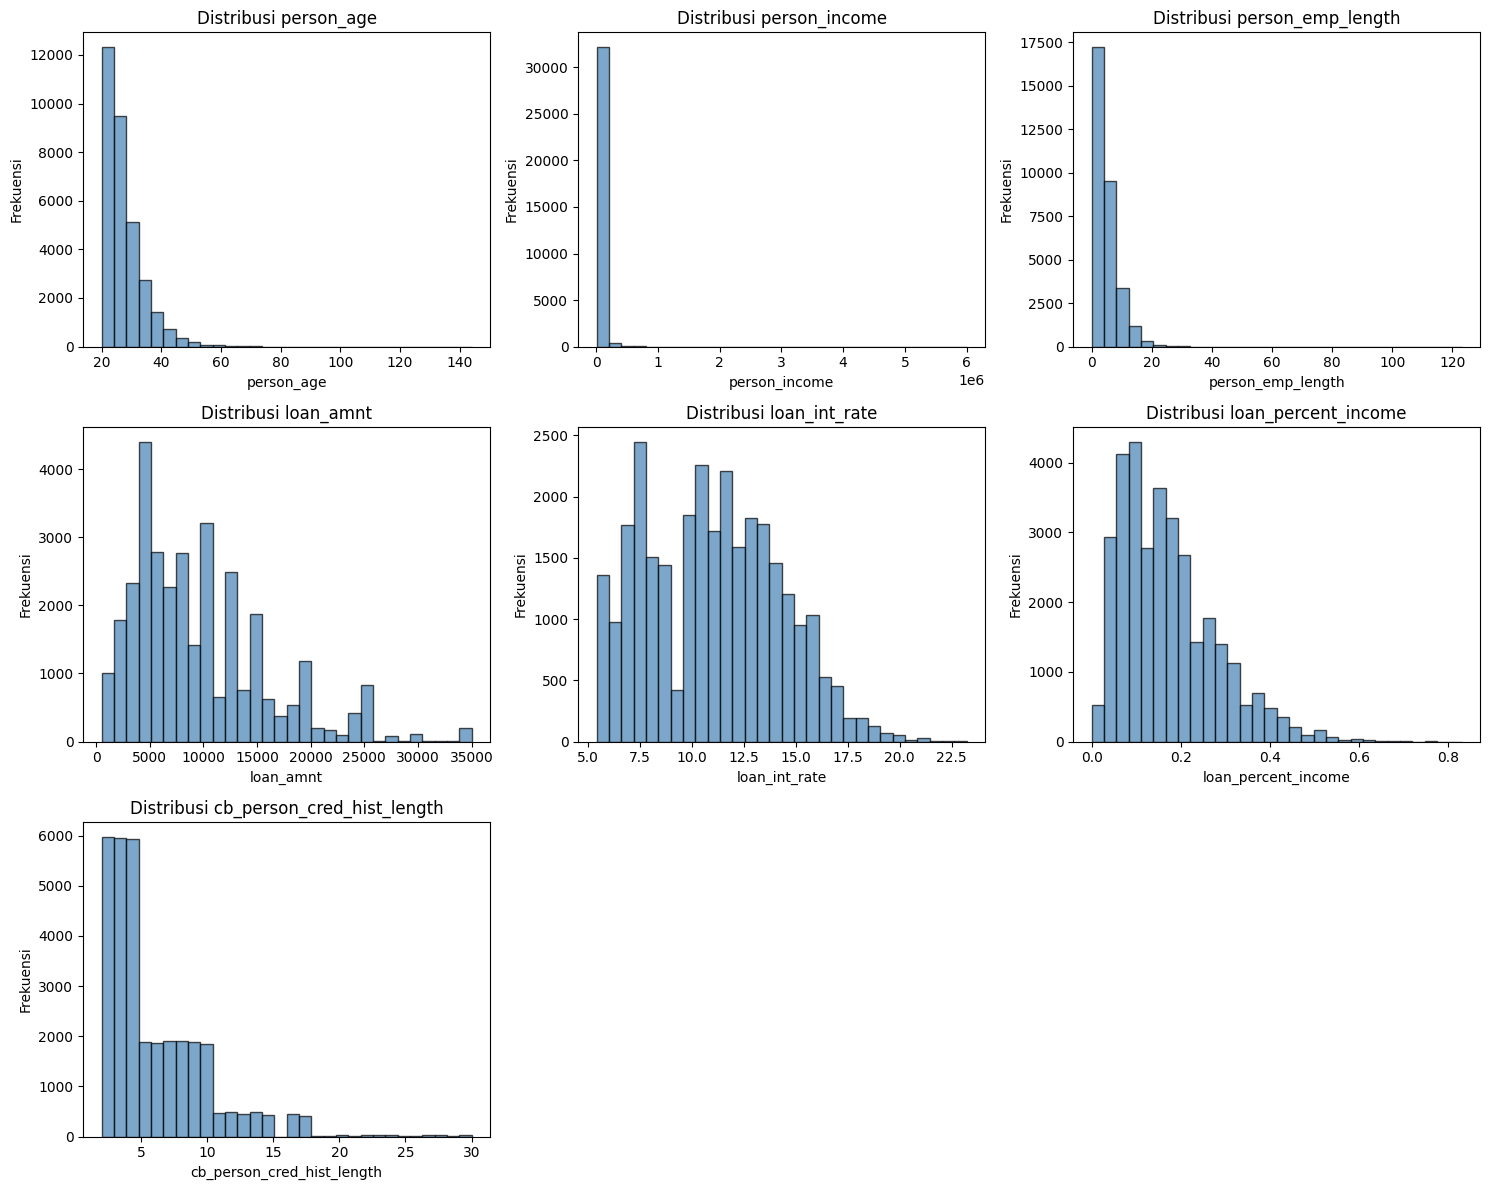

In [26]:
numerical_cols = ['person_age', 'person_income', 'person_emp_length',
                  'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                  'cb_person_cred_hist_length']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

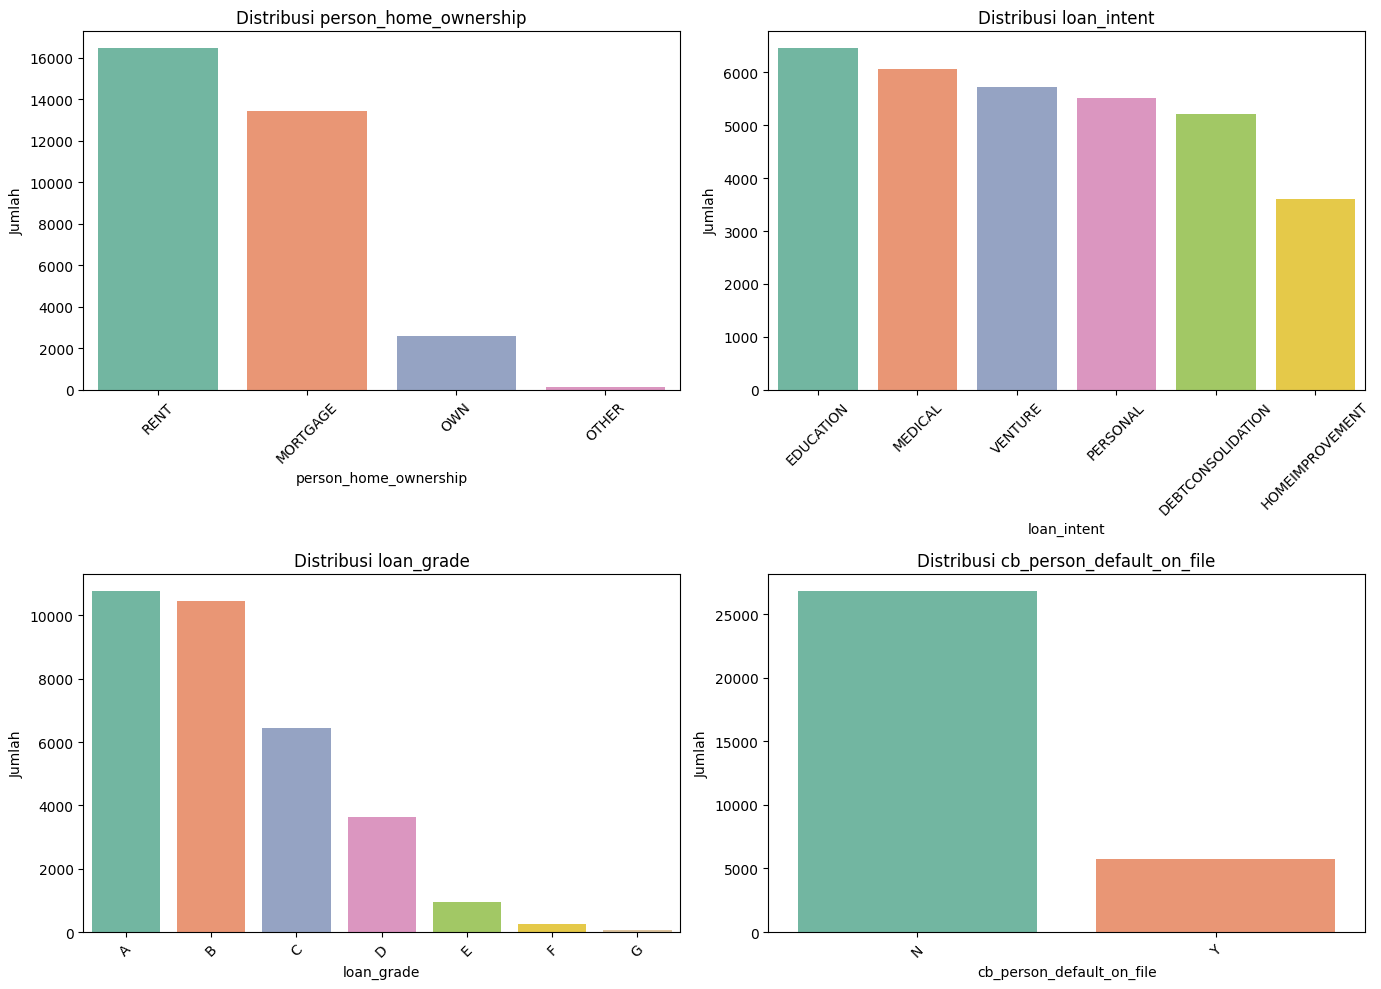

In [27]:
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='Set2')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

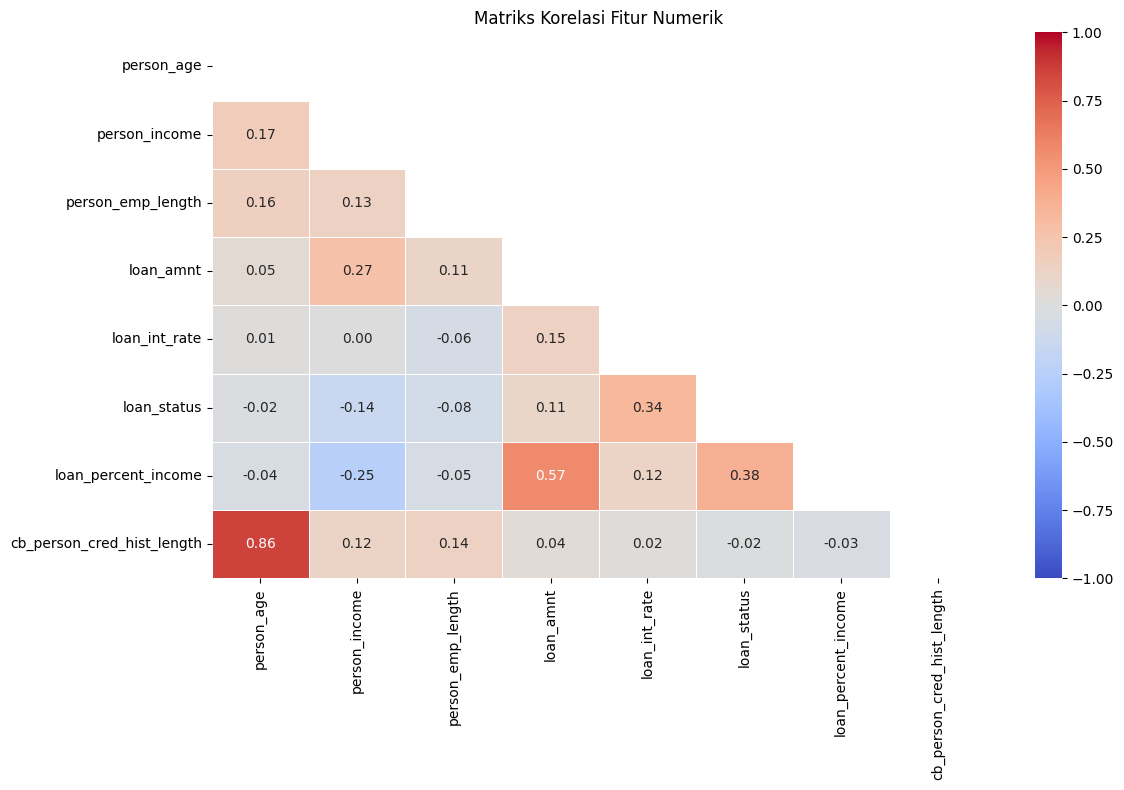

In [28]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

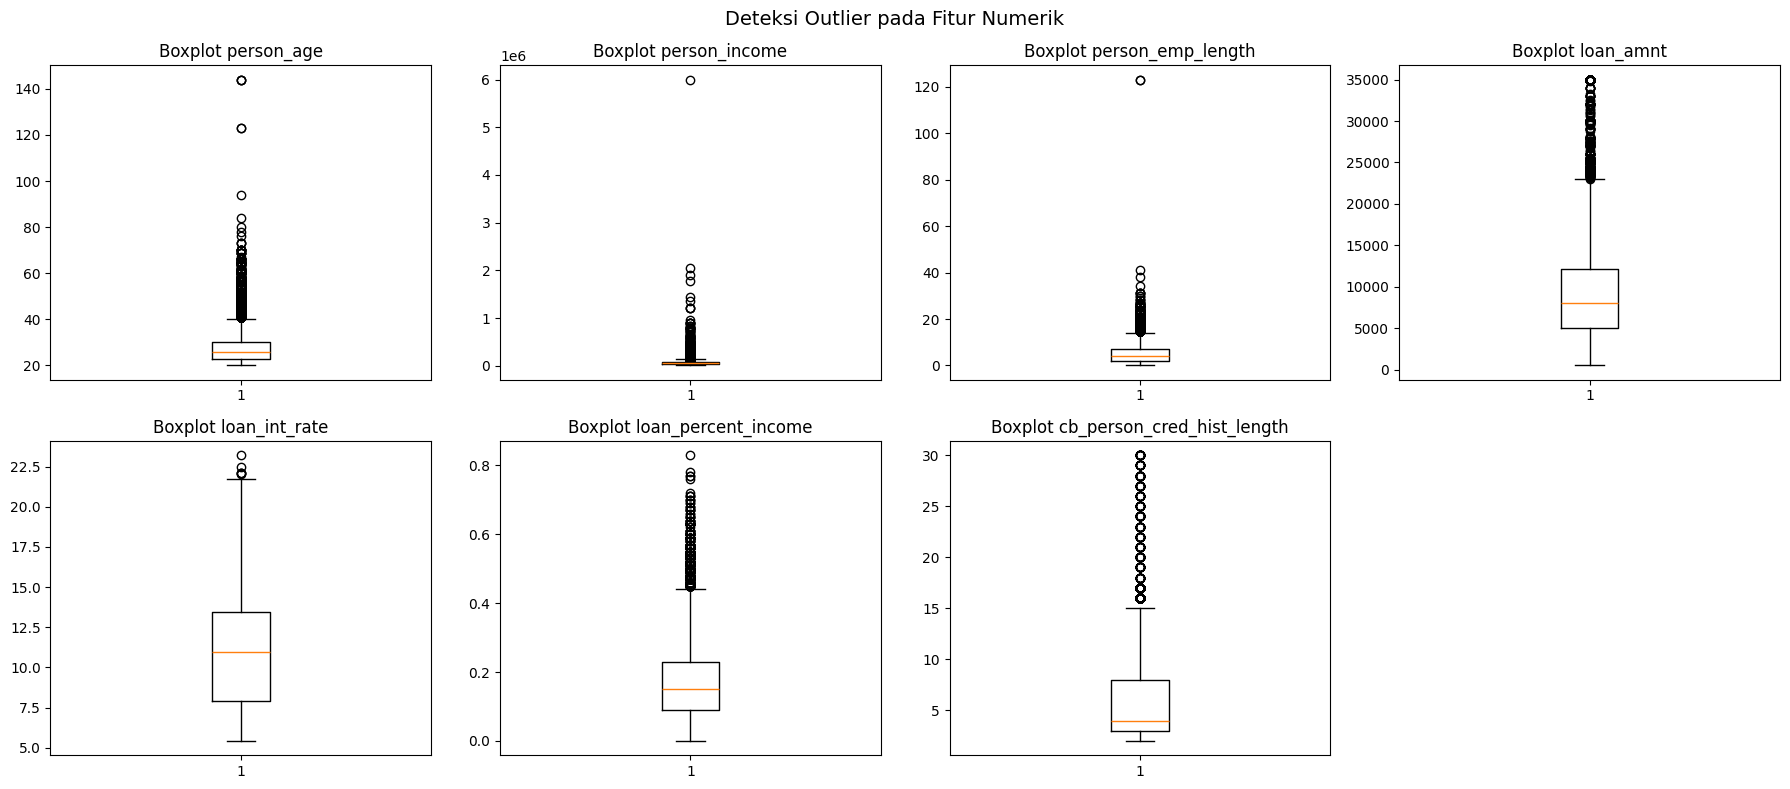

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot {col}')
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Deteksi Outlier pada Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
print('=== Deteksi Outlier ===')
print(f'person_age - Max: {df["person_age"].max()}, Jumlah > 100: {(df["person_age"] > 100).sum()}')
print(f'person_emp_length - Max: {df["person_emp_length"].max()}, Jumlah > 60: {(df["person_emp_length"] > 60).sum()}')

=== Deteksi Outlier ===
person_age - Max: 144, Jumlah > 100: 5
person_emp_length - Max: 123.0, Jumlah > 60: 2


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [31]:
df_clean = df.copy()

# Mengisi missing values pada person_emp_length dengan median
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median())

# Mengisi missing values pada loan_int_rate dengan median
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median())

print('Missing values setelah penanganan:')
print(df_clean.isnull().sum())

Missing values setelah penanganan:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [32]:
print(f'Jumlah data sebelum menghapus outlier: {df_clean.shape[0]}')

# Menghapus outlier pada person_age (> 100 tahun tidak realistis)
df_clean = df_clean[df_clean['person_age'] <= 100]

# Menghapus outlier pada person_emp_length (> 60 tahun tidak realistis)
df_clean = df_clean[df_clean['person_emp_length'] <= 60]

print(f'Jumlah data setelah menghapus outlier: {df_clean.shape[0]}')
print(f'Data yang dihapus: {df.shape[0] - df_clean.shape[0]} baris')

Jumlah data sebelum menghapus outlier: 32581
Jumlah data setelah menghapus outlier: 32574
Data yang dihapus: 7 baris


In [33]:
# Binary encoding untuk cb_person_default_on_file
df_clean['cb_person_default_on_file'] = df_clean['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

# Ordinal encoding untuk loan_grade (A=1 terbaik, G=7 terburuk)
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_clean['loan_grade'] = df_clean['loan_grade'].map(grade_mapping)

# One-hot encoding untuk person_home_ownership dan loan_intent
df_clean = pd.get_dummies(df_clean, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

# Konversi kolom boolean ke integer
bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(f'Jumlah kolom setelah encoding: {df_clean.shape[1]}')
print(f'\nKolom-kolom setelah encoding:')
print(df_clean.columns.tolist())
df_clean.head()

Jumlah kolom setelah encoding: 18

Kolom-kolom setelah encoding:
['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,21,9600,5.0,2,1000,11.14,0,0.10,0,2,0,1,0,1,0,0,0,0
2,25,9600,1.0,3,5500,12.87,1,0.57,0,3,0,0,0,0,0,1,0,0
3,23,65500,4.0,3,35000,15.23,1,0.53,0,2,0,0,1,0,0,1,0,0
4,24,54400,8.0,3,35000,14.27,1,0.55,1,4,0,0,1,0,0,1,0,0
5,21,9900,2.0,1,2500,7.14,1,0.25,0,2,0,1,0,0,0,0,0,1


In [34]:
# Memisahkan fitur dan target
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

# Standarisasi fitur numerik
numerical_features = ['person_age', 'person_income', 'person_emp_length',
                      'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                      'cb_person_cred_hist_length']

scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

print(f'Dimensi fitur (X): {X.shape}')
print(f'Dimensi target (y): {y.shape}')
X.head()

Dimensi fitur (X): (32574, 17)
Dimensi target (y): (32574,)


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,-1.082763,-1.071336,0.060140,2,-1.358831,0.042358,-0.657607,0,-0.938403,0,1,0,1,0,0,0,0
2,-0.438110,-1.071336,-0.944602,3,-0.646823,0.603751,3.745070,0,-0.691721,0,0,0,0,0,1,0,0
3,-0.760436,-0.007205,-0.191046,3,4.020786,1.369583,3.370374,0,-0.938403,0,0,1,0,0,1,0,0
4,-0.599273,-0.218508,0.813697,3,4.020786,1.058058,3.557722,1,-0.445040,0,0,1,0,0,1,0,0
5,-1.082763,-1.065625,-0.693417,1,-1.121495,-1.255662,0.747502,0,-0.938403,0,1,0,0,0,0,0,1


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ukuran data latih: {X_train.shape}')
print(f'Ukuran data uji: {X_test.shape}')
print(f'\nProporsi target pada data latih:')
print(y_train.value_counts(normalize=True).round(4))
print(f'\nProporsi target pada data uji:')
print(y_test.value_counts(normalize=True).round(4))

Ukuran data latih: (26059, 17)
Ukuran data uji: (6515, 17)

Proporsi target pada data latih:
loan_status
0    0.7818
1    0.2182
Name: proportion, dtype: float64

Proporsi target pada data uji:
loan_status
0    0.7819
1    0.2181
Name: proportion, dtype: float64


In [36]:
# Menggabungkan fitur dan target untuk disimpan
preprocessed_data = df_clean.copy()
preprocessed_data.to_csv('credit_risk_preprocessing.csv', index=False)

print(f'Data preprocessing berhasil disimpan ke credit_risk_preprocessing.csv')
print(f'Jumlah data: {preprocessed_data.shape[0]} baris, {preprocessed_data.shape[1]} kolom')

Data preprocessing berhasil disimpan ke credit_risk_preprocessing.csv
Jumlah data: 32574 baris, 18 kolom
